In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

# Loading the data

In [2]:
data_dir = Path("../data")
train_sensor_path = data_dir/"train.csv"
train_demo_path = data_dir/"train_demographics.csv"

In [3]:
sensor_df = pd.read_csv(train_sensor_path)
print(sensor_df.shape)
sensor_df.head()

(574945, 341)


,row_id,sequence_type,sequence_id,sequence_counter,subject,orientation,behavior,phase,gesture,acc_x,...,tof_5_v54,tof_5_v55,tof_5_v56,tof_5_v57,tof_5_v58,tof_5_v59,tof_5_v60,tof_5_v61,tof_5_v62,tof_5_v63
0,SEQ_000007_000000,Target,SEQ_000007,0,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.683594,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,SEQ_000007_000001,Target,SEQ_000007,1,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.949219,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,SEQ_000007_000002,Target,SEQ_000007,2,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,5.722656,...,-1.0,-1.0,112.0,119.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,SEQ_000007_000003,Target,SEQ_000007,3,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.601562,...,-1.0,-1.0,101.0,111.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,SEQ_000007_000004,Target,SEQ_000007,4,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,5.566406,...,-1.0,-1.0,101.0,109.0,125.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [4]:
demo_df = pd.read_csv(train_demo_path)
print(demo_df.shape)
demo_df.columns

(81, 8)


Index(['subject', 'adult_child', 'age', 'sex', 'handedness', 'height_cm',
       'shoulder_to_wrist_cm', 'elbow_to_wrist_cm'],
      dtype='str')

In [5]:
acc_cols = ['acc_x','acc_y','acc_z']
rot_cols = ['rot_w','rot_x','rot_y','rot_z']
imu_cols = acc_cols + rot_cols
thm_cols = [f'thm_{i+1}' for i in range(5)]
tof_cols = [f'tof_{i+1}_v{j}' for i in range(5) for j in range(64)]

In [6]:
sensor_df[imu_cols].describe()

,acc_x,acc_y,acc_z,rot_w,rot_x,rot_y,rot_z
count,574945.000000,574945.000000,574945.000000,571253.000000,571253.000000,571253.000000,571253.000000
mean,1.639980,1.790704,-0.459811,0.360375,-0.119916,-0.059953,-0.188298
std,5.781259,5.003945,6.096490,0.225739,0.465520,0.543028,0.504137
min,-34.585938,-24.402344,-42.855469,0.000000,-0.999146,-0.999695,-0.998169
25%,-2.964844,-2.121094,-5.417969,0.180237,-0.456299,-0.511536,-0.627686
50%,2.972656,0.695312,-1.562500,0.340332,-0.186890,-0.112610,-0.263916
75%,6.343750,6.816406,5.164062,0.503479,0.204590,0.440063,0.251099
max,46.328125,27.183594,30.078125,0.999390,0.999817,0.999451,0.999878


In [7]:
sensor_df[thm_cols].describe()

,thm_1,thm_2,thm_3,thm_4,thm_5
count,567958.000000,567307.000000,568473.000000,568721.000000,541659.000000
mean,27.076450,27.133483,26.702994,27.559114,26.669643
std,3.231948,2.941438,4.122353,2.253639,2.438397
min,-0.370413,21.958820,0.000000,22.375921,22.045000
25%,24.753527,24.543737,24.640350,25.594980,24.556606
50%,26.982324,26.354338,26.956276,27.742224,26.185198
75%,29.425036,29.620147,29.231794,29.267954,28.574785
max,38.457664,37.578339,37.294994,39.588390,37.683292


# Sequence level statistics

In [8]:
sensor_df.sort_values("row_id", ignore_index=True, inplace=True)

In [9]:
imu_readings = sensor_df[imu_cols].to_numpy("float32")
thm_readings = sensor_df[thm_cols].to_numpy("float32")
tof_readings = sensor_df[tof_cols].to_numpy("float16")

In [10]:
seq_meta = sensor_df.groupby("sequence_id", as_index=False, sort=False).agg(
    subject = ("subject", "first"),
    seq_start = ("sequence_id", lambda x: x.index[0]),
    seq_len = ("sequence_id", "size"),
    seq_type = ("sequence_type", "first"),
    orientation = ("orientation", "first"),
    gesture = ("gesture", "first")
)

In [11]:
seq_meta = seq_meta.merge(demo_df, on="subject", how="left")

In [12]:
seq_meta.gesture.value_counts()

gesture
Forehead - pull hairline                      640
Neck - scratch                                640
Neck - pinch skin                             640
Eyelash - pull hair                           640
Forehead - scratch                            640
Text on phone                                 640
Eyebrow - pull hair                           638
Above ear - pull hair                         638
Cheek - pinch skin                            637
Wave hello                                    478
Write name in air                             477
Pull air toward your face                     477
Write name on leg                             161
Feel around in tray and pull out an object    161
Pinch knee/leg skin                           161
Scratch knee/leg skin                         161
Drink from bottle/cup                         161
Glasses on/off                                161
Name: count, dtype: int64

In [13]:
seq_meta.seq_len.describe()

count    8151.000000
mean       70.536744
std        35.389879
min        29.000000
25%        51.000000
50%        59.000000
75%        78.000000
max       700.000000
Name: seq_len, dtype: float64

In [14]:
seq_meta.subject.value_counts()

subject
SUBJ_059520    102
SUBJ_020948    102
SUBJ_040282    102
SUBJ_052342    102
SUBJ_032165    102
              ... 
SUBJ_011323    101
SUBJ_016552     97
SUBJ_038023     96
SUBJ_053217     54
SUBJ_036405     51
Name: count, Length: 81, dtype: int64

In [15]:
seq_meta.handedness.value_counts()

handedness
1    7131
0    1020
Name: count, dtype: int64

# Nature of Missing Values

In [16]:
missing_imus = np.isnan(imu_readings)

In [17]:
missing_imus.sum(axis=0)

array([   0,    0,    0, 3692, 3692, 3692, 3692])

In [18]:
# checking whether all the components of the quaternion are missing for the same timesteps
np.unique(missing_imus.sum(axis=1), return_counts=True)

(array([0, 4]), array([571253,   3692]))

In [19]:
# checking if any sequence has partial timesteps missing
for _, r in seq_meta.iterrows():
    start = r["seq_start"]
    end = start + r["seq_len"]
    missing_quat = missing_imus[start:end, 3:]
    if missing_quat.all() != missing_quat.any():
        print(r["sequence_id"])

Notes for IMU sensor:
* All acceleration values are present
* Some sequences in the training data have all components of quaternion data missing across all timesteps
* There is no sequence that has only a few timesteps of quaternion data missing

In [20]:
missing_tofs = np.isnan(tof_readings)
print(np.unique(missing_tofs.sum(axis=1), return_counts=True))

(array([  0,  64, 320]), array([544803,  23918,   6224]))


In [21]:
for i in range(0,320,64):
    print('\nTime-of-flight sensor number:', i//64+1)
    missing_sum = missing_tofs[:, i:i+64].sum(axis=1)
    print(np.unique(missing_sum, return_counts=True))


Time-of-flight sensor number: 1
(array([ 0, 64]), array([568721,   6224]))

Time-of-flight sensor number: 2
(array([ 0, 64]), array([568721,   6224]))

Time-of-flight sensor number: 3
(array([ 0, 64]), array([568721,   6224]))

Time-of-flight sensor number: 4
(array([ 0, 64]), array([568721,   6224]))

Time-of-flight sensor number: 5
(array([ 0, 64]), array([544803,  30142]))


In [22]:
# checking if a sequence has partial timesteps missing (via the 5th tof sensor)
for _, r in seq_meta.iterrows():
    start = r["seq_start"]
    end = start + r["seq_len"]
    missing_tof = missing_tofs[start:end, 64*4:]
    if missing_tof.all() != missing_tof.any():
        print(r["sequence_id"])

SEQ_062104


Notes for time-of-flight sensor:
* There is no case where partial pixels are missing for a timestep for any tof sensor
* The 5th tof sensor has almost 5 times the missing timesteps as the other tof sensors
* Some sequences in the training data have all the timesteps missing for all the tof sensors
* There are sequences that have all the timesteps missing for the 5th tof sensor but all the timesteps for the other tof sensors are present
* Exactly one sequence (SEQ_062104) has some timesteps of the 5th tof sensor missing (other tof sensors have complete data)

# Effect of handedness

In [23]:
left_mask = np.zeros(imu_readings.shape[0], dtype=np.bool)
for _, r in seq_meta.iterrows():
    start = r["seq_start"]
    end = start + r["seq_len"]
    left_mask[start:end] = (r["handedness"]==0)

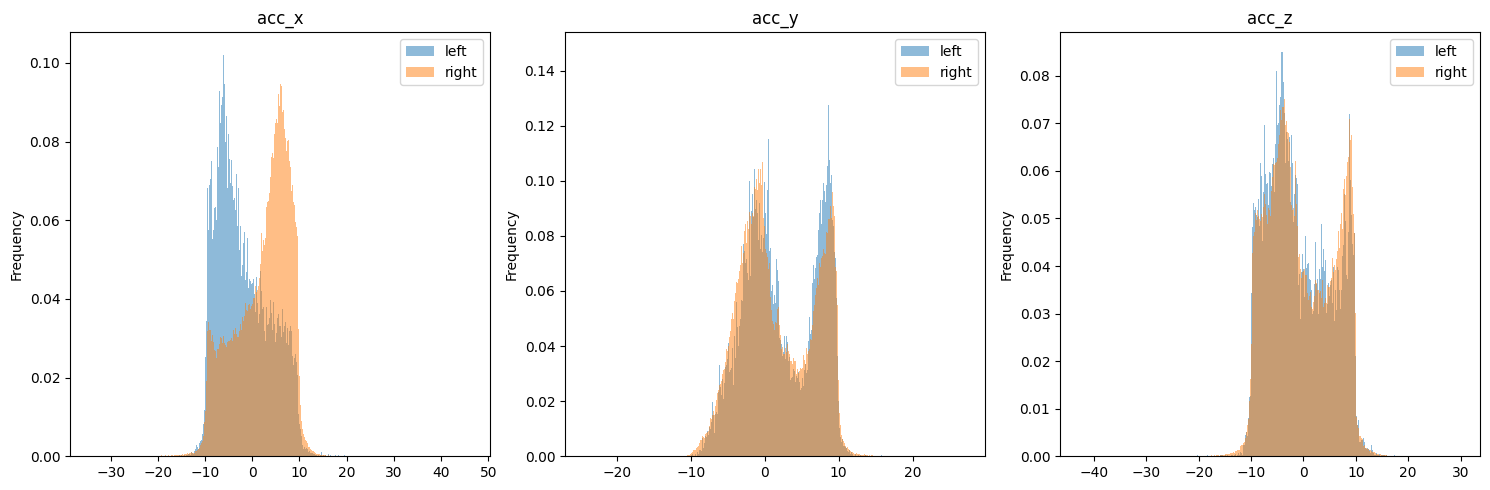

In [24]:
fig, axes = plt.subplots(1, len(acc_cols), figsize=(15,5))

for col, ax in zip(acc_cols, axes):
    sensor_df.loc[left_mask, col].plot(
        kind='hist', ax=ax, label='left', bins=500, density=True, alpha=0.5
    )
    sensor_df.loc[~left_mask, col].plot(
        kind='hist', ax=ax, label='right', bins=500, density=True, alpha=0.5
    )
    ax.set_title(col); ax.legend()

fig.tight_layout()

It is clear that `acc_x` needs a sign flip to normalize for handedness. The majority of other deviations in distributions probably come from some gestures not being mirror images when performed with left and right hands. Visualizing histograms per gesture might be more precise.

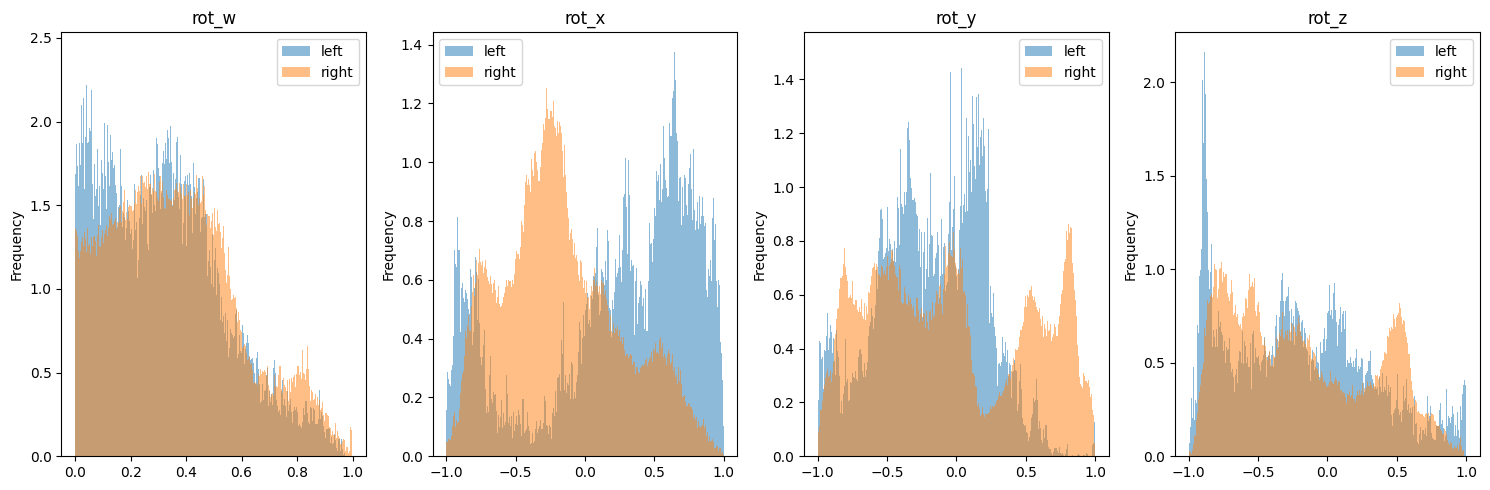

In [25]:
fig, axes = plt.subplots(1, len(rot_cols), figsize=(15,5))

for col, ax in zip(rot_cols, axes):
    sensor_df.loc[left_mask, col].plot(
        kind='hist', ax=ax, label='left', bins=500, density=True, alpha=0.5
    )
    sensor_df.loc[~left_mask, col].plot(
        kind='hist', ax=ax, label='right', bins=500, density=True, alpha=0.5
    )
    ax.set_title(col); ax.legend()

fig.tight_layout()

In [26]:
def get_rel_rot(quat):
    rot = R.from_quat(quat, scalar_first=True)
    rel = (rot[:-1].inv() * rot[1:]).as_rotvec()
    pad = np.zeros((1,3), dtype=quat.dtype)
    rel = np.concatenate([pad, rel], axis=0)
    return rel.astype(quat.dtype)

def impute_quat(quat):
    quat = np.where(np.isnan(quat), np.array([1,0,0,0]), quat)
    return quat

In [27]:
rel_rots = np.zeros((imu_readings.shape[0], 3), dtype=np.float32)
for _, r in seq_meta.iterrows():
    start = r["seq_start"]
    end = start + r["seq_len"]
    quat = imu_readings[start:end, 3:]
    quat = impute_quat(quat)
    rel_rots[start:end] = get_rel_rot(quat)

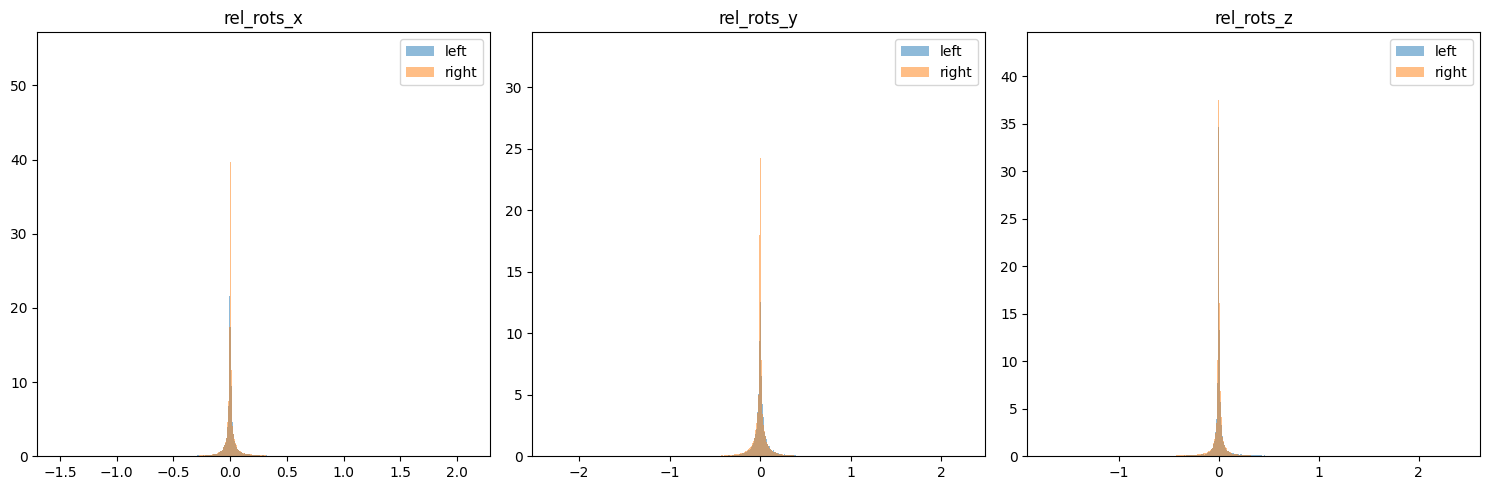

In [28]:
dirs = ["x","y","z"]
fig, axes = plt.subplots(1, rel_rots.shape[1], figsize=(15,5))

for i, ax in enumerate(axes):
    l = rel_rots[left_mask, i]
    ax.hist(l, bins=500, density=True, label="left", alpha=0.5)
    r = rel_rots[~left_mask, i]
    ax.hist(r, bins=500, density=True, label="right", alpha=0.5)
    ax.set_title(f"rel_rots_{dirs[i]}"); ax.legend()

fig.tight_layout()

# Saving readings as numpy arrays

In [29]:
max_gesture_name_len = seq_meta.gesture.str.len().max()
max_subject_name_len = seq_meta.subject.str.len().max()

In [ ]:
out_dir = data_dir/"processed"

np.save(out_dir/"imu.npy", imu_readings)
np.save(out_dir/"thm.npy", thm_readings)
np.save(out_dir/"tof.npy", tof_readings)
np.savez(
    out_dir/"metadata.npz", seq_starts=seq_meta.seq_start.to_numpy(),
    seq_lens=seq_meta.seq_len.to_numpy(),
    gestures=seq_meta.gesture.to_numpy(f"<U{max_gesture_name_len}"),
    subjects=seq_meta.subject.to_numpy(f"<U{max_subject_name_len}"),
    handedness=seq_meta.handedness.to_numpy("bool")
)